In [18]:
import tensorflow as tf

# 1. 导入数据集 mnist
from tensorflow.keras.datasets import mnist

# 2. 从 layer 模块导入 Dense 和 Activation
from tensorflow.keras.layers import Dense, Activation

# 3. 从 optimizers 模块导入 SGD
from tensorflow.keras.optimizers import SGD
# 或者使用旧版本路径，以防兼容性问题
# from tensorflow.keras.optimizers.legacy import SGD

# 4. 从 utils 模块导入 np_utils
from tensorflow.keras.utils import to_categorical as np_utils

In [19]:
print("--- 1. 加载 MNIST 数据集 ---")

# 使用mnist模块的load_data方法加载数据集
# 它会将数据自动解包到训练集和测试集的特征/标签变量中
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("\n--- 2. 查看四个变量的维度 (Shape) ---")

# 检查训练集特征 (X_train) 的维度
print(f"X_train (训练集特征) 维度: {X_train.shape}")

# 检查训练集标签 (y_train) 的维度
print(f"y_train (训练集标签) 维度: {y_train.shape}")

# 检查测试集特征 (X_test) 的维度
print(f"X_test (测试集特征) 维度: {X_test.shape}")

# 检查测试集标签 (y_test) 的维度
# 注意：您的要求是 (X_test, yest)，但正确变量名应该是 y_test
print(f"y_test (测试集标签) 维度: {y_test.shape}")

print("\n--- 3. 维度说明 ---")
print("维度正确性验证:")
print(f"* 训练集图像数量: {X_train.shape[0]} 张")
print(f"* 测试集图像数量: {X_test.shape[0]} 张")
print(f"* 图像尺寸: {X_train.shape[1]} 像素 x {X_train.shape[2]} 像素 (28x28)")

--- 1. 加载 MNIST 数据集 ---

--- 2. 查看四个变量的维度 (Shape) ---
X_train (训练集特征) 维度: (60000, 28, 28)
y_train (训练集标签) 维度: (60000,)
X_test (测试集特征) 维度: (10000, 28, 28)
y_test (测试集标签) 维度: (10000,)

--- 3. 维度说明 ---
维度正确性验证:
* 训练集图像数量: 60000 张
* 测试集图像数量: 10000 张
* 图像尺寸: 28 像素 x 28 像素 (28x28)


In [20]:
# 假设 X_train 和 X_test 已经从上一步加载并拥有正确的初始形状 (60000, 28, 28) 和 (10000, 28, 28)

# ----------------------------------------------------
# 步骤 1: 展平 (Reshape) 数据
# ----------------------------------------------------
# X_train 形状从 60000x28x28 变为 60000x784 (28*28=784)
X_train = X_train.reshape(60000, 784)

# X_test 形状从 10000x28x28 变为 10000x784
X_test = X_test.reshape(10000, 784)

print("--- 1. 数据展平后的形状检查 ---")
print(f"X_train 展平后的形状: {X_train.shape}")
print(f"X_test 展平后的形状: {X_test.shape}")


# ----------------------------------------------------
# 步骤 2: 转换数据类型 (astype)
# ----------------------------------------------------
# 将元素的默认数据类型（通常是 uint8）改为 float32
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# ----------------------------------------------------
# 步骤 3: 验证形状和数据类型
# ----------------------------------------------------
print("\n--- 2. 最终形状和数据类型验证 ---")

# 验证 X_train 的形状和数据类型
print("X_train 最终验证:")
print(f"  形状 (Shape): {X_train.shape}")
print(f"  数据类型 (dtype): {X_train.dtype}")

# 验证 X_test 的形状和数据类型
print("X_test 最终验证:")
print(f"  形状 (Shape): {X_test.shape}")
print(f"  数据类型 (dtype): {X_test.dtype}")

--- 1. 数据展平后的形状检查 ---
X_train 展平后的形状: (60000, 784)
X_test 展平后的形状: (10000, 784)

--- 2. 最终形状和数据类型验证 ---
X_train 最终验证:
  形状 (Shape): (60000, 784)
  数据类型 (dtype): float32
X_test 最终验证:
  形状 (Shape): (10000, 784)
  数据类型 (dtype): float32


In [21]:
# 假设 X_train 和 X_test 已经从上一步展平并转换为了 float32 类型

print("--- 1. 执行特征归一化 (Normalization) ---")

# 归一化操作：将所有像素值除以 255.0
# 因为 X_train 和 X_test 已经是 float32 类型，可以直接进行浮点除法
X_train /= 255.0
X_test /= 255.0

print("归一化完成：像素值已缩放到 0.0 到 1.0 之间。")


# ----------------------------------------------------
# 步骤 2: 查看 X_train 归一化后的部分值进行验证
# ----------------------------------------------------
print("\n--- 2. 检查 X_train 归一化后的第 2 个例子 (索引 1) 的部分像素值 ---")

# 查看 X_train 的第 2 个例子（索引为 1）的第 100 个到第 150 个像素点的值
# X_train[1] 代表第 2 个例子
# X_train[1][99:150] 代表其第 100 个到第 150 个像素点（Python 索引从 0 开始，所以是 99 到 150）
print(X_train[1][99:150])

--- 1. 执行特征归一化 (Normalization) ---
归一化完成：像素值已缩放到 0.0 到 1.0 之间。

--- 2. 检查 X_train 归一化后的第 2 个例子 (索引 1) 的部分像素值 ---
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.2        0.62352943
 0.99215686 0.62352943 0.19607843 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        ]


In [22]:
# 导入 to_categorical 方法
from tensorflow.keras.utils import to_categorical

print("--- 1. 执行 One-Hot 编码 ---")

# MNIST 数据集的类别总数是 0 到 9，共 10 个类别。
NUM_CLASSES = 10

# 对训练集标签进行 One-Hot 编码
Y_train = to_categorical(y_train, num_classes=NUM_CLASSES)

# 对测试集标签进行 One-Hot 编码
Y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

print("One-Hot 编码完成。")


# ----------------------------------------------------
# 步骤 2: 打印 Y_train 前五行进行验证
# ----------------------------------------------------
print("\n--- 2. 检查 Y_train 前五行的 One-Hot 编码结果 ---")

# 打印 Y_train 编码后的前五行
print(Y_train[:5])

--- 1. 执行 One-Hot 编码 ---
One-Hot 编码完成。

--- 2. 检查 Y_train 前五行的 One-Hot 编码结果 ---
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [23]:
# 导入所需的模块
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("--- 1. 创建序列模型对象 ---")
model = Sequential()
print("模型对象创建成功。")


print("\n--- 2. 添加两个隐藏层和输出层 ---")

# **第一层 (隐藏层 1)**
# 2.1 输入层/第一个隐藏层：(784 -> 128, 激活函数 'relu')
model.add(Dense(
    units=128, 
    input_shape=(784,), # 指定第一层的输入形状
    activation='relu'
))

# **第二层 (隐藏层 2)**
# 2.2 添加第二个隐藏层：(128 -> 128, 激活函数 'relu')
model.add(Dense(
    units=128, 
    activation='relu'
))

# **第三层 (输出层)**
# 2.3 添加输出层：(128 -> 10, 激活函数 'softmax')
model.add(Dense(
    units=10, 
    activation='softmax'
))

print("三个全连接层添加成功。")


print("\n--- 3. 查看的模型摘要 (Summary) ---")

# 3. 通过 model.summary() 查看模型结构和参数数量
model.summary()

--- 1. 创建序列模型对象 ---
模型对象创建成功。

--- 2. 添加两个隐藏层和输出层 ---
三个全连接层添加成功。

--- 3. 查看的模型摘要 (Summary) ---
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 128)               100480    
                                                                 
 dense_6 (Dense)             (None, 128)               16512     
                                                                 
 dense_7 (Dense)             (None, 10)                1290      
                                                                 
Total params: 118,282
Trainable params: 118,282
Non-trainable params: 0
_________________________________________________________________


In [24]:
# 从 metrics 模块导入 Precision 和 Recall 类
from tensorflow.keras.metrics import Precision, Recall

print("--- 1. 定义优化器和指标 ---")

sgd_optimizer = SGD() 

# 创建一个包含多个指标的列表
custom_metrics = [
    'accuracy',       # 默认的准确率 (CategoricalAccuracy 的简写)
    Precision(),      # 精确率 (使用类的形式)
    Recall()          # 召回率 (使用类的形式)
]


print("\n--- 2. 编译模型 (Compile) ---")

# 编译模型，将指标列表传递给 metrics 参数
model.compile(
    # 损失函数: 适用于 One-Hot 编码标签的多分类任务
    loss='categorical_crossentropy', 
    
    # 优化器: 使用实例化好的 SGD 优化器对象
    optimizer=sgd_optimizer,
    
    # 评估指标: 使用包含多个指标的列表
    metrics=custom_metrics
)

print("模型编译完成！")
print(f"使用的损失函数 (Loss): categorical_crossentropy")
print(f"使用的优化器 (Optimizer): SGD")
print(f"使用的评估指标 (Metrics): {custom_metrics}")

--- 1. 定义优化器和指标 ---

--- 2. 编译模型 (Compile) ---
模型编译完成！
使用的损失函数 (Loss): categorical_crossentropy
使用的优化器 (Optimizer): SGD
使用的评估指标 (Metrics): ['accuracy', <keras.metrics.metrics.Precision object at 0x000002673AB957C0>, <keras.metrics.metrics.Recall object at 0x000002673AB9D190>]


In [25]:
# 假设 model, X_train, Y_train 变量已准备就绪

print("--- 1. 开始训练神经网络模型 (model.fit) ---")

# 调用 fit 方法训练模型
# 训练过程的结果将存储在 history 对象中
history = model.fit(
    x=X_train,              # 输入数据（特征）
    y=Y_train,              # 标签数据（已 One-Hot 编码）
    batch_size=128,         # 每次梯度下降使用的样本数
    epochs=20,             # 总共训练的轮次
    verbose=1,              # 以进度条形式输出日志信息
    validation_split=0.2    # 从 X_train/Y_train 中划分 20% 作为验证集
)

print("\n--- 训练完成！ ---")

--- 1. 开始训练神经网络模型 (model.fit) ---
Epoch 1/20
375/375 [==============================] - 3s 7ms/step - loss: 1.4867 - accuracy: 0.6128 - precision_2: 0.9744 - recall_2: 0.1713 - val_loss: 0.7482 - val_accuracy: 0.8383 - val_precision_2: 0.9744 - val_recall_2: 0.5942
Epoch 2/20
375/375 [==============================] - 2s 6ms/step - loss: 0.5907 - accuracy: 0.8526 - precision_2: 0.9461 - recall_2: 0.7172 - val_loss: 0.4505 - val_accuracy: 0.8827 - val_precision_2: 0.9451 - val_recall_2: 0.8091
Epoch 3/20
375/375 [==============================] - 1s 3ms/step - loss: 0.4330 - accuracy: 0.8821 - precision_2: 0.9360 - recall_2: 0.8223 - val_loss: 0.3723 - val_accuracy: 0.8957 - val_precision_2: 0.9412 - val_recall_2: 0.8539
Epoch 4/20
375/375 [==============================] - 3s 8ms/step - loss: 0.3743 - accuracy: 0.8953 - precision_2: 0.9351 - recall_2: 0.8558 - val_loss: 0.3348 - val_accuracy: 0.9032 - val_precision_2: 0.9403 - val_recall_2: 0.8724
Epoch 5/20
375/375 [==================

In [26]:
# 假设 model 对象已训练完成，且 X_test, Y_test 已准备就绪

print("--- 1. 使用 model.evaluate 在测试集上评估模型 ---")

# 1) 使用 model 对象的 evaluate 方法来评估模型
# x 和 y 分别传入测试集特征和标签
# verbose=1 会显示评估过程的进度条
score = model.evaluate(
    x=X_test, 
    y=Y_test, 
    verbose=1
)

print("\n--- 2. 打印评估结果 (Score) ---")

# evaluate 方法返回一个包含损失值和所有评估指标的列表。
# 顺序对应于您在 model.compile 中 metrics=['loss', 'accuracy', ...] 的顺序。

# 假设我们在编译时 metrics=['accuracy', Precision(), Recall()]
# score[0] 是损失值 (loss)
# score[1] 是准确率 (accuracy)

# 2) 打印 score 的第一项和第二项值
print("总损失值 (Loss):", score[0])
print("准确率 (Accuracy):", score[1])
print("精确率 (Precision):", score[2])
print("召回率 (Recall):", score[3])

--- 1. 使用 model.evaluate 在测试集上评估模型 ---
313/313 [==============================] - 1s 2ms/step - loss: 0.1835 - accuracy: 0.9456 - precision_2: 0.9585 - recall_2: 0.9350

--- 2. 打印评估结果 (Score) ---
总损失值 (Loss): 0.18348702788352966
准确率 (Accuracy): 0.9455999732017517
精确率 (Precision): 0.9584828019142151
召回率 (Recall): 0.9350000023841858


1/1 [==============================] - 0s 34ms/step


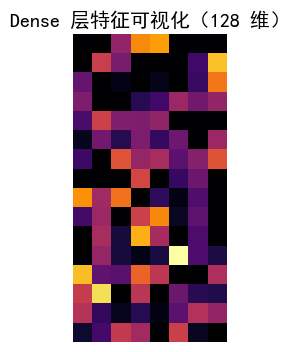

In [28]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# --- 中文字体设置 ---
# 1. 检查系统中是否存在 SimHei 字体 (最常见的中文支持字体)
#    如果 SimHei 不存在，可能需要手动安装，或改为使用其他常见字体如 'Microsoft YaHei'
try:
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体
except ValueError:
    print("SimHei 字体未找到，尝试使用系统默认字体...")
    # 备用方案：使用系统默认的 sans-serif 字体
    pass

plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像时负号 '-' 显示为方块的问题
from keras.models import Model
# 取模型第一层（Dense层）的输出
layer_output = model.layers[0].output

# 定义子模型，将输入图像映射到第一层 Dense 的输出
feature_model = Model(inputs=model.input, outputs=layer_output)

# 随机选一张图像
index = 0
img = X_train[index].reshape(1, 784)   # 已展平后的输入格式

# 获取特征
features = feature_model.predict(img)

# 特征是 128 维，将其 reshape 为 16×8 用灰度图可视化
feature_img = features.reshape(16, 8)

plt.figure(figsize=(4, 4))
plt.imshow(feature_img, cmap='inferno')
plt.title("Dense 层特征可视化（128 维）")
plt.axis('off')
plt.show()